#  Exploratory Data Analysis

In this notebook, we explore the cleaned online retail dataset to identify sales trends, product performance, customer behavior, and geographic patterns.

##  Import Libraries

We import the required Python libraries for data analysis and visualization.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [16]:
df = pd.read_csv('data/online_retail_cleaned.csv', parse_dates=['InvoiceDate'])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 779,425 rows × 9 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


##  Create Time Features

We create additional date-based features to analyze sales trends over time.

In [17]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()

print("✓ Time-based features created")
df[['InvoiceDate', 'YearMonth', 'Month', 'Hour', 'Weekday']].head()

✓ Time-based features created


,InvoiceDate,YearMonth,Month,Hour,Weekday
0,2009-12-01 07:45:00,2009-12,12,7,Tuesday
1,2009-12-01 07:45:00,2009-12,12,7,Tuesday
2,2009-12-01 07:45:00,2009-12,12,7,Tuesday
3,2009-12-01 07:45:00,2009-12,12,7,Tuesday
4,2009-12-01 07:45:00,2009-12,12,7,Tuesday


##  Monthly Revenue Trend

We examine how total revenue changes over time on a monthly basis.

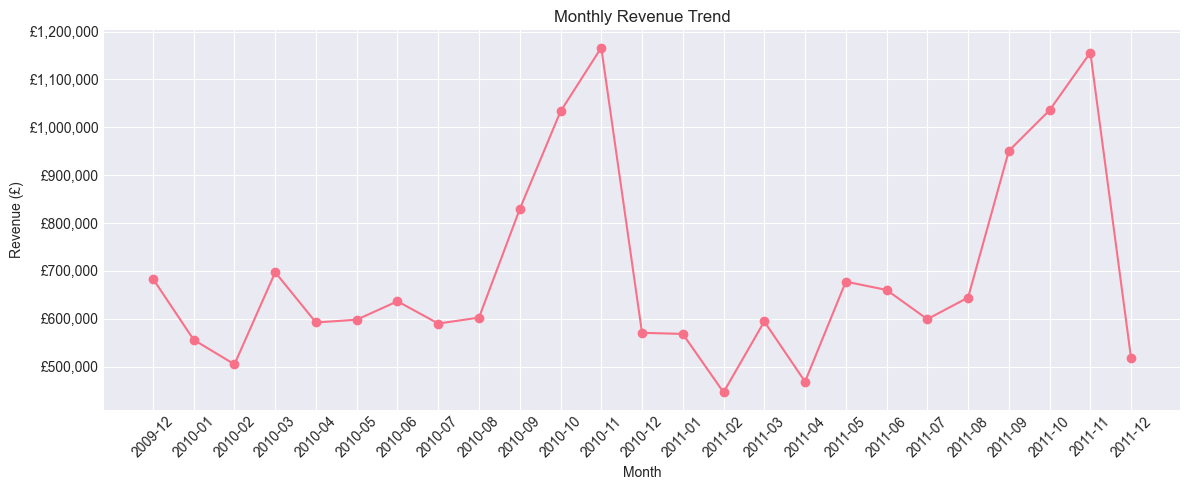

In [18]:
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/figures/monthly_revenue.png')
plt.show()


##  Revenue by Hour

We analyze which hours of the day generate the most revenue.

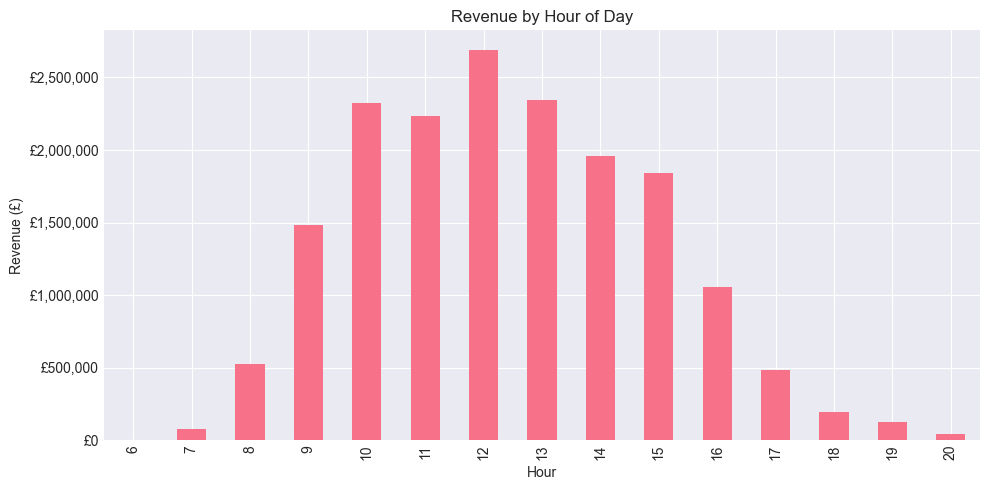

In [19]:
hourly_revenue = df.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(10, 5))
hourly_revenue.plot(kind='bar')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

##  Revenue by Weekday

We explore sales performance across the days of the week.

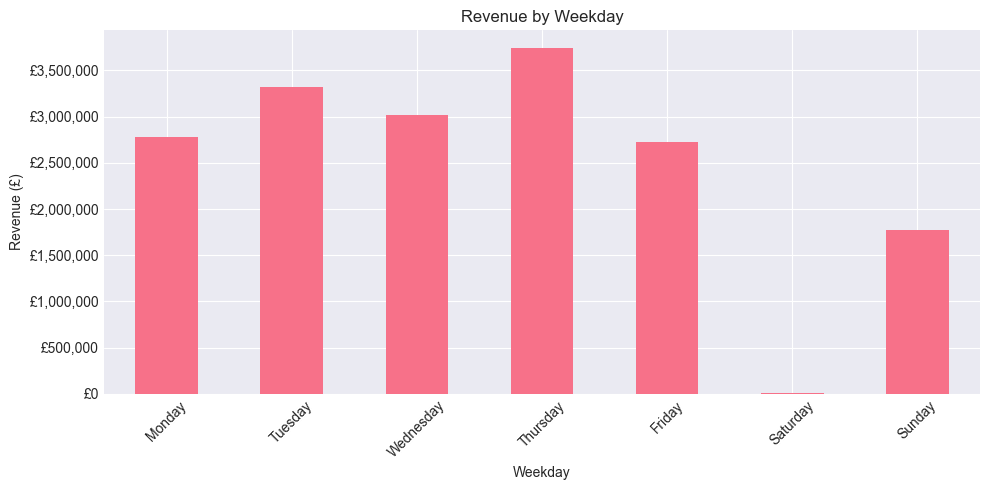

In [20]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue = df.groupby('Weekday')['TotalPrice'].sum().reindex(weekday_order)

plt.figure(figsize=(10, 5))
weekday_revenue.plot(kind='bar')
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/figures/weekday_revenue.png')
plt.show()


##  Top Products by Revenue

We identify the products that generate the highest total revenue.

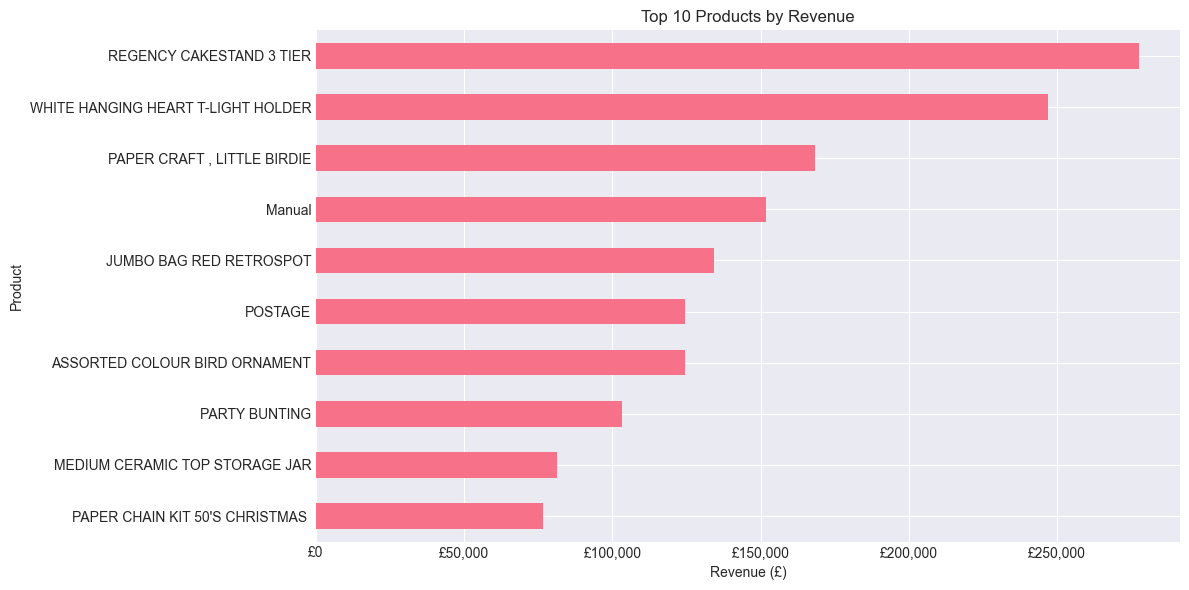

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64

In [21]:
top_products_revenue = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products_revenue.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/figures/top_products_revenue.png')
plt.show()

top_products_revenue


##  Top Products by Quantity Sold

We also examine which products are sold in the highest quantities.

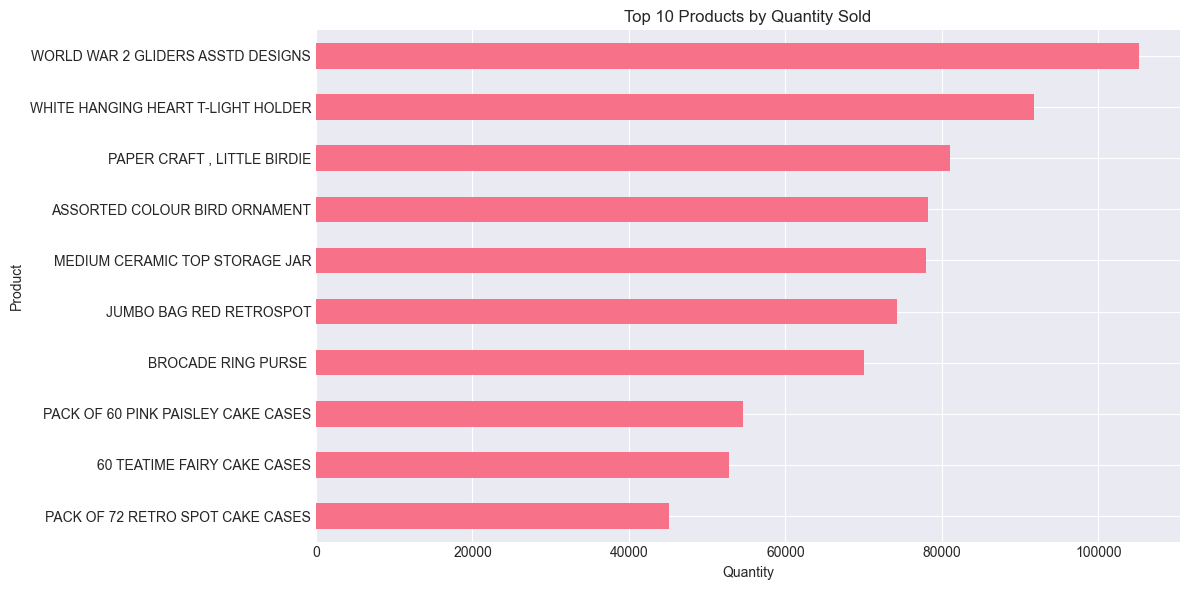

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

In [22]:
top_products_quantity = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products_quantity.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

top_products_quantity

##  Customer Analysis

We aggregate customer-level metrics to understand purchasing behavior.

In [23]:
customer_stats = df.groupby('Customer ID').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Total_Items=('Quantity', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

customer_stats['Avg_Order_Value'] = customer_stats['Total_Revenue'] / customer_stats['Total_Orders']

print(f"Unique customers: {len(customer_stats):,}")
customer_stats.head()

Unique customers: 5,878


,Customer ID,Total_Revenue,Total_Orders,Total_Items,First_Purchase,Last_Purchase,Avg_Order_Value
0,12346.0,77556.46,12,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,6463.038333
1,12347.0,4921.53,8,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,615.191250
2,12348.0,2019.40,5,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,403.880000
3,12349.0,4428.69,4,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,1107.172500
4,12350.0,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


##  Top Customers by Revenue

We identify the highest-value customers based on total revenue generated.

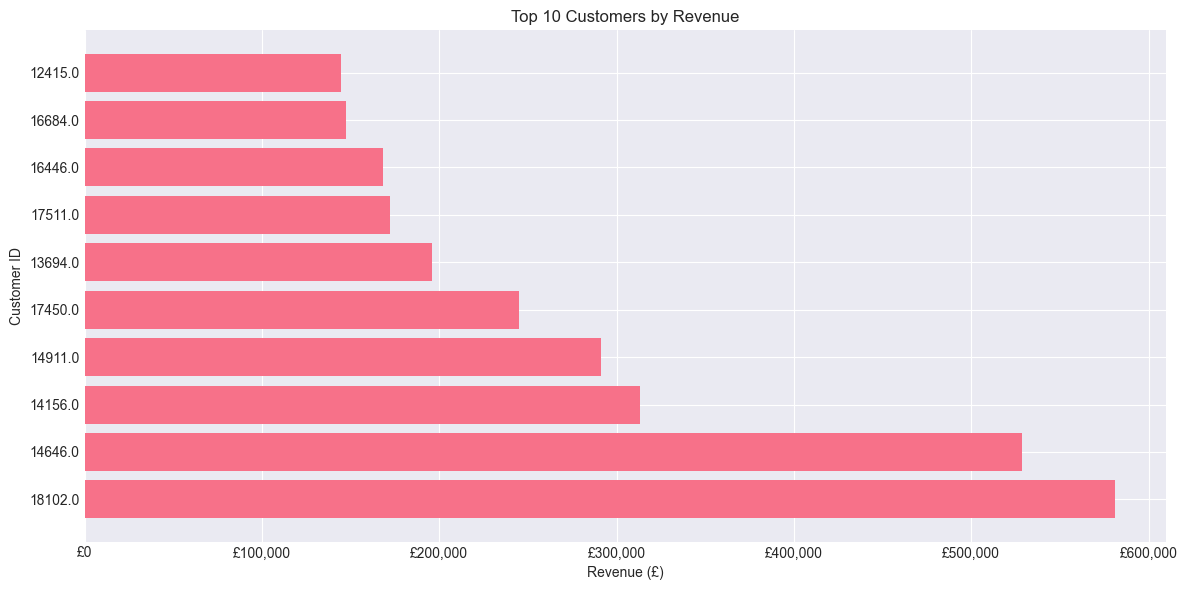

,Customer ID,Total_Revenue,Total_Orders,Avg_Order_Value
5692,18102.0,580987.04,145,4006.807172
2277,14646.0,528602.52,151,3500.678940
1789,14156.0,313437.62,156,2009.215513
2538,14911.0,291420.81,398,732.213090
5050,17450.0,244784.25,51,4799.691176
1331,13694.0,195640.69,143,1368.116713
5109,17511.0,172132.87,60,2868.881167
4061,16446.0,168472.50,2,84236.250000
4295,16684.0,147142.77,55,2675.323091
68,12415.0,144458.37,28,5159.227500


In [24]:
top_customers = customer_stats.sort_values(by='Total_Revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_customers['Customer ID'].astype(str), top_customers['Total_Revenue'])
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Customer ID')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/figures/top_customers.png')
plt.show()



top_customers[['Customer ID', 'Total_Revenue', 'Total_Orders', 'Avg_Order_Value']]

##  Geographic Analysis

We analyze which countries contribute the most revenue.

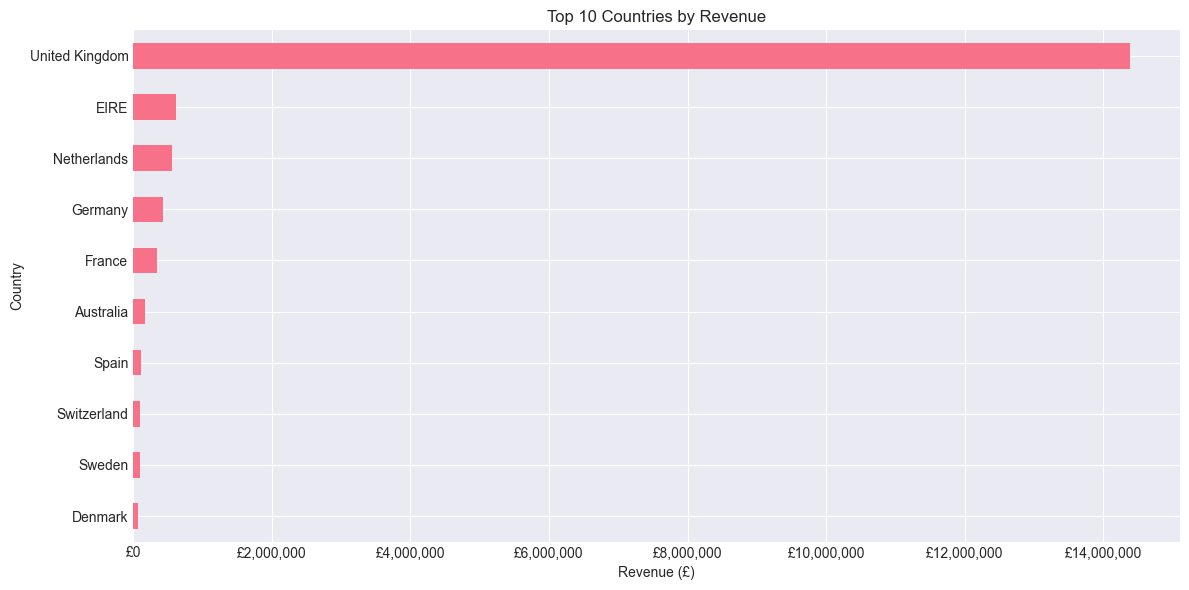

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

In [25]:
country_revenue = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
country_revenue.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

country_revenue

##  Order / Basket Analysis

We analyze order-level metrics such as average order value and average number of items per order.

In [26]:
order_stats = df.groupby('Invoice').agg(
    Order_Revenue=('TotalPrice', 'sum'),
    Items_in_Order=('Quantity', 'sum'),
    Unique_Products=('StockCode', 'nunique')
).reset_index()

print("=" * 50)
print("ORDER / BASKET STATISTICS")
print("=" * 50)
print(f"Total Orders         : {len(order_stats):,}")
print(f"Average Order Value  : £{order_stats['Order_Revenue'].mean():,.2f}")
print(f"Avg Items per Order  : {order_stats['Items_in_Order'].mean():,.2f}")
print(f"Avg Unique Products  : {order_stats['Unique_Products'].mean():,.2f}")
print("=" * 50)

ORDER / BASKET STATISTICS
Total Orders         : 36,969
Average Order Value  : £469.98
Avg Items per Order  : 284.40
Avg Unique Products  : 20.80


##  Distribution of Order Values

We visualize how order values are distributed across transactions.

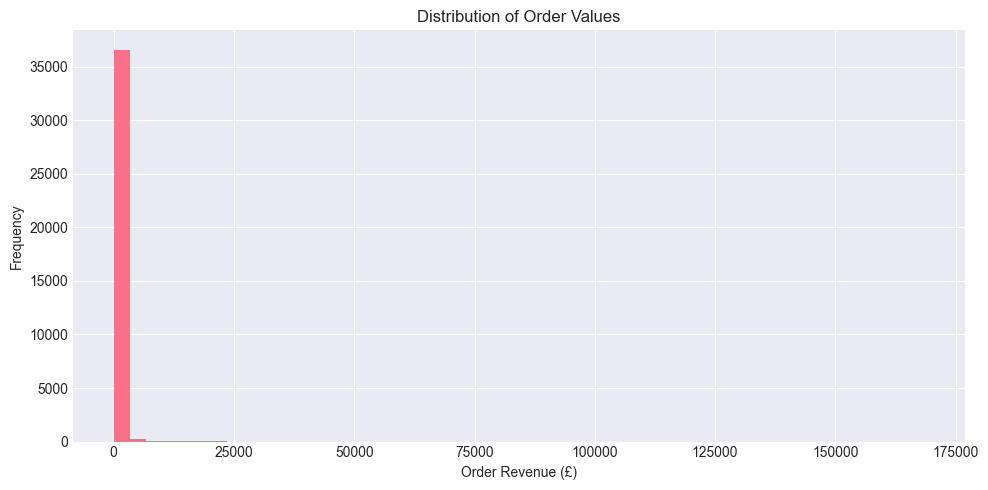

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(order_stats['Order_Revenue'], bins=50)
plt.title('Distribution of Order Values')
plt.xlabel('Order Revenue (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##  Key Findings

This section summarizes the most important findings from the exploratory analysis.

### Key Findings

- Revenue shows clear variation over time, with some months generating significantly higher sales than others.
- Sales activity is concentrated during specific hours of the day, reflecting customer purchasing patterns.
- A small number of products generate a large share of total revenue.
- High-revenue products are not always the same as high-volume products.
- Customer revenue is unevenly distributed, with a small group of customers contributing disproportionately.
- The United Kingdom dominates total revenue, while a smaller number of international markets contribute the remaining share.
- Basket-level analysis shows that average order value and item counts vary substantially across transactions.

##  Save Analysis Outputs

We save useful analysis tables for the next notebook.

In [28]:
customer_stats.to_csv('data/customer_stats.csv', index=False)
order_stats.to_csv('data/order_stats.csv', index=False)

print("✓ Analysis outputs saved successfully")

✓ Analysis outputs saved successfully
